In [1]:
from scipy.optimize import fsolve
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def solve_for_alpha(u, v, initial_guess=0.0):
    """
    Solves the equation: alpha + 1 - 2(u + v) + v * 2^(-alpha) = 0
    """
    # Define the equation as a function of alpha
    def equation(alpha):
        return alpha + 1 - 2*(u + v) + v * (2.0 ** (-alpha))
    
    # fsolve returns an array, we extract the first element
    alpha_solution = fsolve(equation, initial_guess, xtol=1e-10)[0]
    
    # Verify the solution is close to zero (optional checking)
    tolerance = 1e-6
    if abs(equation(alpha_solution)) > tolerance:
        print("Warning: The solver may not have converged to a true root.")
        
    return alpha_solution

In [2]:
def compute_yn(n, u, v):
    yns = np.zeros(n+1)
    sums = np.zeros(n+1)

    yns[0] = 1
    yns[1] = 1
    yns[2] = 2*u + 2*v

    sums[0] = 1
    sums[1] = 2
    sums[2] = 2*u + 2*v + 2

    for i in range(3, n+1):
        yns[i] = (2*u*sums[i-1] + 2*v*(sums[i-1] - sums[(i-1)//2-1])) / i
        sums[i] = sums[i-1] + yns[i]

    return yns 

Computed alpha: 0.5213031132052071


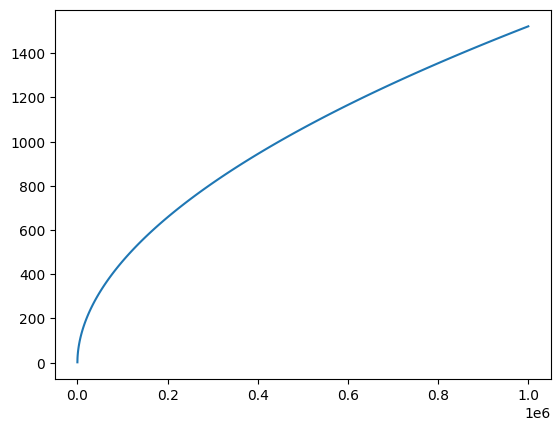

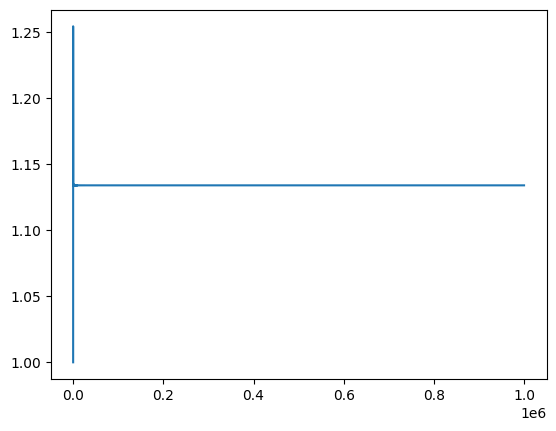

In [6]:
N = 1000000
u = 0.5
v = 0.4

yns = compute_yn(N, u, v)
alpha = solve_for_alpha(u, v, initial_guess=1.0)
print(f"Computed alpha: {alpha}") 

plt.plot(np.arange(1, N+1), yns[1:], label='Y_n')
plt.show()

plt.plot(np.arange(1, N+1), yns[1:] / np.arange(1, N+1)**alpha, label='Y_n')
plt.show()

##### $y_{n+2} = \dfrac{2}{n}\sum\limits_{i=1}^{n}y_i + 1, \quad y_1=y_2=0$

In [14]:
def compute_yns(n):
  history = np.zeros(n+1)
  sums = np.zeros(n+1)

  history[1] = history[2] = 0
  sums[1] = sums[2] = 0

  for i in range(3, n+1):
    history[i] = sums[i-2]*2/(i-2) + 1
    sums[i] = sums[i-1] + history[i]

 
  return history


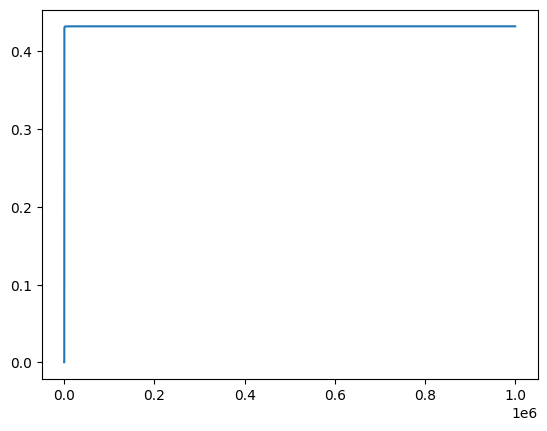

Final scaling factor: 0.4323317907140408


In [15]:
N = 1000000
yns = compute_yns(N)
alpha = 1

plt.plot(np.arange(1, N+1), yns[1:]/np.arange(1, N+1)**alpha, label='Y_n')
plt.show()

print("Final scaling factor:", yns[-1]/N**alpha)

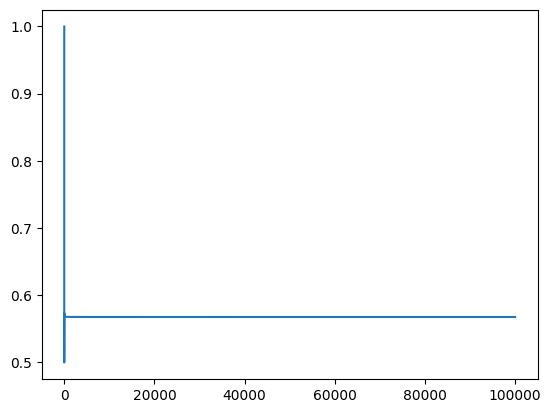

In [9]:
N = 100000

x0 = 1
x1 = 1

history = np.zeros(N+1)
scaled_sums = np.zeros(N+1)

history[0] = history[1] = 1
scaled_sums[0] = 0*x0
scaled_sums[1] = 0*x0 + 1*x1

for i in range(2, N+1):
  history[i] = scaled_sums[i-2]*2/((i-1)*i) + 1/i
  scaled_sums[i] = scaled_sums[i-1] + history[i]*i

plt.plot(np.arange(1, N+1), history[1:], label='Y_n')
plt.show()
